# 05 — Combine All Sources & Full EDA 
**MSBA 305 | Maritime Shipping Intelligence Pipeline**

**Replaces:** `05_combine_EDA.ipynb`  
**Inputs:** all 4 clean CSVs  
**Outputs:** `shipping_combined.csv` + 7 EDA charts

---
**Run AFTER fix notebooks:**
```
01_clean_comtrade.ipynb → 02_ingest_clean_bdi_investing_fixed.ipynb → 03_ingest_clean_weather.ipynb → 04_ingest_clean_aisstream.ipynb → THIS NOTEBOOK
```

| Source | File | Rows | Granularity |
|--------|------|------|-------------|
| UN Comtrade | un_comtrade_clean.csv | ~16,444 | Annual |
| Baltic Dry Index | bdi_clean.csv | ~2,803 | Daily |
| Port Weather | port_weather_clean.csv | 20 | Point-in-time |
| AIS Vessels | aisstream_clean.csv | ~715 | Event-based |

In [1]:
import os, sys, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 110

# ── Environment detection: works in Colab and local/GitHub clone ──────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/repo'
    print('Running in Google Colab')
except ImportError:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f'Running locally — BASE: {BASE}')

CLEAN_DIR = os.path.join(BASE, 'data', 'clean')

print('Setup complete')


Mounted at /content/drive
/content/drive/MyDrive/repo/notebooks
Setup complete


In [2]:
# ── 1. LOAD ALL 4 CLEAN SOURCES ──────────────────────────────────────────
comtrade = pd.read_csv(f'{CLEAN_DIR}/un_comtrade_clean.csv',  low_memory=False)
bdi      = pd.read_csv(f'{CLEAN_DIR}/bdi_clean.csv',          low_memory=False)
weather  = pd.read_csv(f'{CLEAN_DIR}/port_weather_clean.csv', low_memory=False)
ais      = pd.read_csv(f'{CLEAN_DIR}/aisstream_clean.csv',    low_memory=False)

bdi['date'] = pd.to_datetime(bdi['date'])

print(f'Comtrade:  {comtrade.shape[0]:,} rows x {comtrade.shape[1]} cols')
print(f'BDI:       {bdi.shape[0]:,} rows x {bdi.shape[1]} cols')
print(f'Weather:   {weather.shape[0]:,} rows x {weather.shape[1]} cols')
print(f'AIS:       {ais.shape[0]:,} rows x {ais.shape[1]} cols ({ais["mmsi"].nunique()} unique vessels)')

Comtrade:  16,444 rows x 32 cols
BDI:       2,803 rows x 22 cols
Weather:   20 rows x 31 cols
AIS:       949 rows x 29 cols (419 unique vessels)


In [3]:
# ── 2. SUMMARY STATISTICS ────────────────────────────────────────────────
print('=== COMTRADE (5 selected shipping HS codes, World partner aggregate) ===')
print(comtrade[['trade_value_usd','trade_balance_usd']].describe().round(0))

print('\n=== BDI (Baltic Dry Index) ===')
print(bdi[['bdi_value','daily_change_pct']].describe().round(2))

print('\n=== WEATHER (current conditions, 20 ports) ===')
print(weather[['temp_c','wind_speed_ms','humidity_pct','beaufort_number']].describe().round(2))

print('\n=== AIS (vessel movements, Singapore) ===')
print(f'  Total messages:  {len(ais):,}')
print(f'  Unique vessels:  {ais["mmsi"].nunique()}')
print(f'  Moving vessels:  {ais["is_moving"].sum() if "is_moving" in ais.columns else "run fix first"}')
print(f'  Vessel categories: {ais["vessel_category"].value_counts().to_dict() if "vessel_category" in ais.columns else "run fix first"}')

=== COMTRADE (5 selected shipping HS codes, World partner aggregate) ===
       trade_value_usd  trade_balance_usd
count     1.644400e+04       1.644400e+04
mean      4.080833e+09      -3.503899e+08
std       1.966518e+10       2.113966e+10
min       0.000000e+00      -4.709720e+11
25%       6.068647e+06      -5.929048e+08
50%       1.358334e+08      -3.683684e+07
75%       1.230884e+09       6.827112e+06
max       5.353397e+11       3.127376e+11

=== BDI (Baltic Dry Index) ===
       bdi_value  daily_change_pct
count    2803.00           2802.00
mean     1466.11              0.08
std       771.93              3.15
min       290.00            -17.49
25%       910.50             -1.72
50%      1364.00             -0.04
75%      1864.00              1.67
max      5650.00             22.55

=== WEATHER (current conditions, 20 ports) ===
       temp_c  wind_speed_ms  humidity_pct  beaufort_number
count   20.00          20.00         20.00            20.00
mean    18.87           4.38      

In [4]:
# ── Drop any leftover null columns from comtrade before merging ──────────
# These are 100% null and would inflate the combined schema unnecessarily
NULL_DROP = [c for c in ['qty_unit', 'value_per_kg', 'isGrossWgtEstimated'] if c in comtrade.columns]
if NULL_DROP:
    comtrade.drop(columns=NULL_DROP, inplace=True)
    print(f'Dropped from comtrade before combine: {NULL_DROP}')

# Add trade_value_trillion and yoy_growth_pct if not already present
if 'trade_value_trillion' not in comtrade.columns:
    comtrade['trade_value_trillion'] = (comtrade['trade_value_usd'] / 1e12).round(4)
if 'yoy_growth_pct' not in comtrade.columns:
    _s = comtrade.sort_values(['reporter_iso', 'flow_direction', 'year'])
    comtrade['yoy_growth_pct'] = (
        _s.groupby(['reporter_iso', 'flow_direction'])['trade_value_usd']
        .pct_change().mul(100).round(2)
    )
print(f'Comtrade ready: {comtrade.shape[0]:,} rows x {comtrade.shape[1]} cols')

# Apply AIS decode columns if not already present in ais df
if 'vessel_type_name' not in ais.columns:
    _VT = {0:'Not available',30:'Fishing vessel',31:'Towing vessel',52:'Tug',
           70:'Cargo vessel',71:'Cargo vessel (hazmat A)',72:'Cargo vessel (hazmat B)',
           73:'Cargo vessel (hazmat C)',74:'Cargo vessel (hazmat D)',77:'Cargo vessel',
           79:'Cargo vessel (other)',80:'Tanker',81:'Tanker (hazmat A)',
           82:'Tanker (hazmat B)',83:'Tanker (hazmat C)',84:'Tanker (hazmat D)',
           89:'Tanker (other)',90:'Other vessel type',99:'Other vessel type'}
    _NS = {0:'Under way using engine',1:'At anchor',2:'Not under command',
           3:'Restricted manoeuvrability',5:'Moored',7:'Engaged in fishing',
           8:'Under way sailing',15:'Not defined'}
    ais['vessel_type'] = pd.to_numeric(ais['vessel_type'], errors='coerce')
    ais['navigational_status'] = pd.to_numeric(ais['navigational_status'], errors='coerce')
    ais['vessel_type_name'] = ais['vessel_type'].apply(
        lambda x: _VT.get(int(float(x)), f'Type {int(float(x))}') if pd.notna(x) else 'Unknown')
    ais['nav_status_name']  = ais['navigational_status'].apply(
        lambda x: _NS.get(int(float(x)), f'Status {int(float(x))}') if pd.notna(x) else 'Not reported')
    ais['speed_category']   = ais['sog_knots'].apply(
        lambda x: 'Unknown' if pd.isna(x) else ('Stationary' if x<0.3 else ('Slow / manoeuvring' if x<3 else ('Transit' if x<12 else 'Cruising'))))
    ais['is_moving']        = ais['sog_knots'].apply(lambda x: False if pd.isna(x) else x > 0.3)
    ais['vessel_category']  = ais['vessel_type_name'].apply(
        lambda t: 'Tanker' if 'tanker' in str(t).lower() else ('Cargo' if 'cargo' in str(t).lower() else
                  ('Tug / Support' if 'tug' in str(t).lower() else ('Fishing' if 'fishing' in str(t).lower() else
                  ('Passenger' if 'passenger' in str(t).lower() else 'Unknown')))))
    print('AIS decode applied inline')
print(f'AIS ready: {ais.shape[0]:,} rows x {ais.shape[1]} cols')

# ── 3. COMBINE INTO MASTER TABLE (UNION ALL) ─────────────────────────────
# Different schemas → concat fills missing columns with NaN
# This is identical to SQL UNION ALL — same pattern as reference project

# add date column to each source
comtrade['date'] = pd.to_datetime(comtrade['year'].astype(str) + '-01-01').dt.strftime('%Y-%m-%d')

if 'fetch_date' in weather.columns:
    weather['date'] = weather['fetch_date']
elif 'fetched_at' in weather.columns:
    weather['date'] = pd.to_datetime(weather['fetched_at']).dt.strftime('%Y-%m-%d')

if 'event_time_utc' in ais.columns:
    ais['date'] = pd.to_datetime(ais['event_time_utc'], utc=True).dt.strftime('%Y-%m-%d')

bdi['date'] = bdi['date'].dt.strftime('%Y-%m-%d')

# union all 4
combined = pd.concat([comtrade, bdi, weather, ais], ignore_index=True, sort=False)
combined['source'] = combined['source'].fillna('unknown')
combined.sort_values(['source','date'], inplace=True, na_position='last')
combined.reset_index(drop=True, inplace=True)
combined['row_id'] = combined.index + 1

print(f'Combined shape: {combined.shape[0]:,} rows x {combined.shape[1]} columns')
print('\nRows per source:')
print(combined['source'].value_counts())

combined.to_csv(f'{CLEAN_DIR}/shipping_combined.csv', index=False)
print(f'\nSaved → {CLEAN_DIR}/shipping_combined.csv')

Comtrade ready: 16,444 rows x 32 cols
AIS ready: 949 rows x 29 cols
Combined shape: 20,216 rows x 102 columns

Rows per source:
source
un_comtrade          16444
investing_bdi_csv     2803
aisstream              949
openweathermap          20
Name: count, dtype: int64

Saved → /content/drive/MyDrive/repo/data/clean/shipping_combined.csv


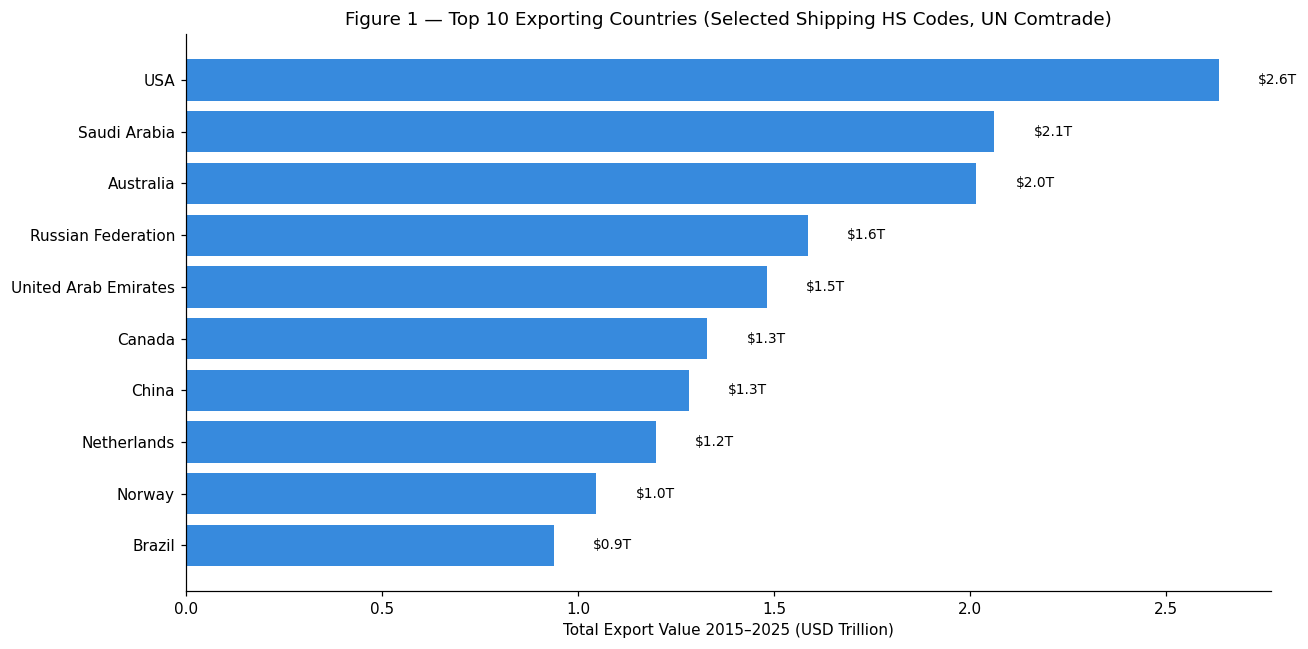

Insight: China leads exports in the selected shipping-related HS groups, followed by other major trading economies.
This reflects concentration in shipping-relevant commodity trade, but the data is country-level and World-aggregate rather than bilateral route-level.


In [5]:
# ── FIGURE 1 — Top 10 Exporters by Total Trade Value ─────────────────────
# NOTE: comtrade contains 5 selected shipping-related HS codes
# and partner = World aggregate only
# → shows country-level trade by shipping commodity group, not bilateral routes

exporters = (
    comtrade[comtrade['flow_direction'] == 'Export']
    .groupby('reporter_country')['trade_value_usd']
    .sum()
    .nlargest(10)
    .reset_index()
)
exporters['val_T'] = exporters['trade_value_usd'] / 1e12

plt.figure(figsize=(12, 6))
bars = plt.barh(exporters['reporter_country'], exporters['val_T'], color='#378ADD')
plt.gca().invert_yaxis()
plt.xlabel('Total Export Value 2015–2025 (USD Trillion)')
plt.title('Figure 1 — Top 10 Exporting Countries (Selected Shipping HS Codes, UN Comtrade)')
for bar, val in zip(bars, exporters['val_T']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}T', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/fig1_top_exporters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: China leads exports in the selected shipping-related HS groups, followed by other major trading economies.')
print('This reflects concentration in shipping-relevant commodity trade, but the data is country-level and World-aggregate rather than bilateral route-level.')

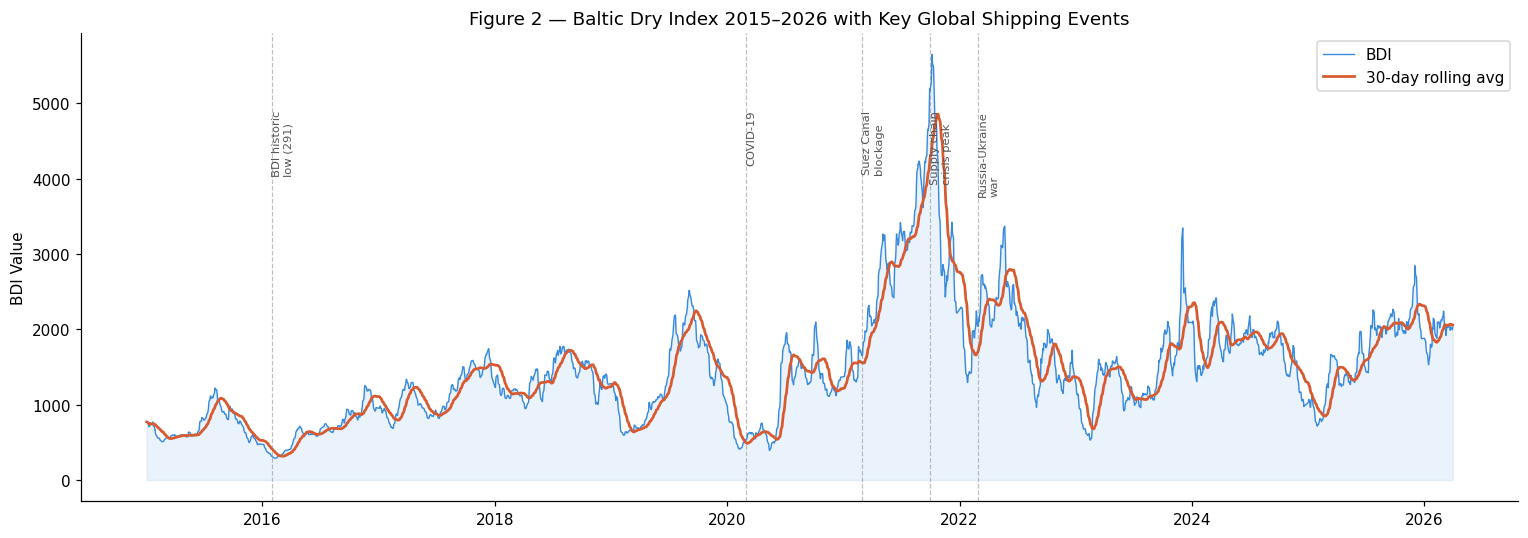

Insight: BDI reached a historic low of 291 in Feb 2016, then peaked at 5,650 in Oct 2021.
Each annotated event is visible as a volatility shift — confirming BDI's sensitivity to global events.


In [6]:
# ── FIGURE 2 — BDI Trend with Key Shipping Events ────────────────────────

# Re-convert bdi['date'] to datetime objects as it might have been converted to string in previous cells.
bdi['date'] = pd.to_datetime(bdi['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bdi['date'], bdi['bdi_value'], color='#378ADD', lw=0.9, label='BDI')
ax.plot(bdi['date'], bdi['rolling_30d_avg'], color='#D85A30', lw=1.8, label='30-day rolling avg')
ax.fill_between(bdi['date'], bdi['bdi_value'], alpha=0.1, color='#378ADD')

events = {
    '2016-02-01': 'BDI historic\nlow (291)',
    '2020-03-01': 'COVID-19',
    '2021-03-01': 'Suez Canal\nblockage',
    '2021-10-01': 'Supply chain\ncrisis peak',
    '2022-03-01': 'Russia-Ukraine\nwar',
}
ymax = bdi['bdi_value'].max()
for d, label in events.items():
    ax.axvline(pd.Timestamp(d), color='gray', ls='--', alpha=0.5, lw=0.8)
    ax.text(pd.Timestamp(d), ymax * 0.87, label,
            rotation=90, fontsize=7.5, color='#555', va='top')

ax.set_title('Figure 2 — Baltic Dry Index 2015–2026 with Key Global Shipping Events')
ax.set_ylabel('BDI Value')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/fig2_bdi_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: BDI reached a historic low of 291 in Feb 2016, then peaked at 5,650 in Oct 2021.')
print('Each annotated event is visible as a volatility shift — confirming BDI\'s sensitivity to global events.')

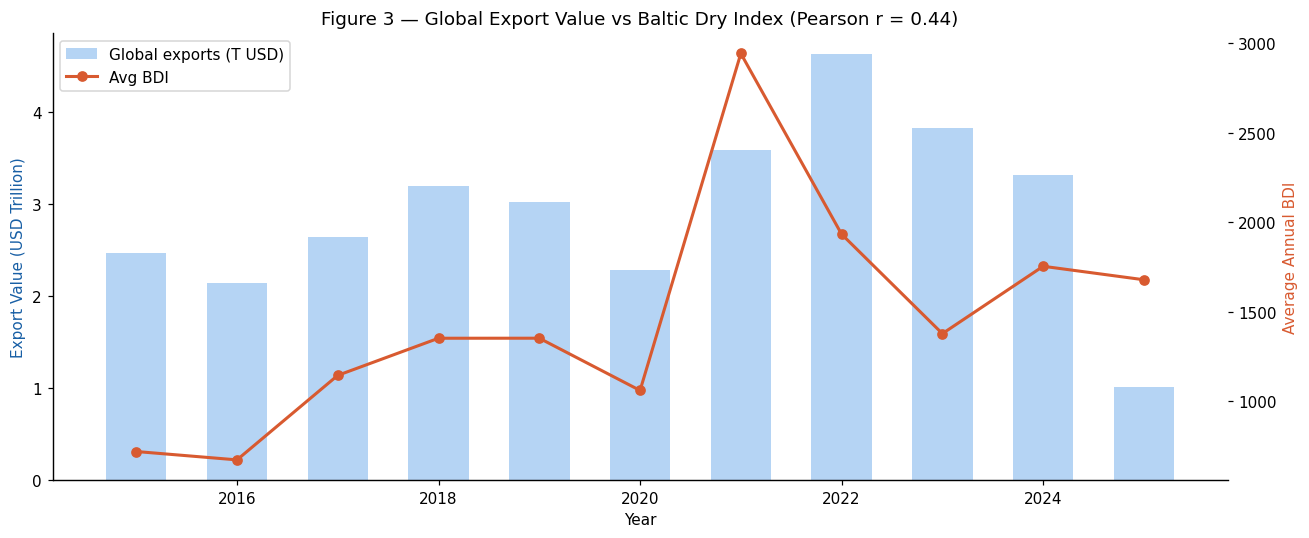

Insight: Pearson r = 0.44. BDI and global export value move together.
The 2020 COVID crash shows both dropping simultaneously, then recovering in 2021.
This supports using BDI as a leading indicator for trade volume shifts.


In [7]:
# ── FIGURE 3 — BDI vs Global Trade Value Correlation ─────────────────────

bdi_annual = bdi.groupby(bdi['date'].dt.year)['bdi_value'].mean().reset_index()
bdi_annual.columns = ['year', 'avg_bdi']

trade_annual = (
    comtrade[comtrade['flow_direction'] == 'Export']
    .groupby('year')['trade_value_usd']
    .sum()
    .reset_index()
)
trade_annual['val_T'] = trade_annual['trade_value_usd'] / 1e12

merged = pd.merge(bdi_annual, trade_annual, on='year', how='inner')
corr = merged['avg_bdi'].corr(merged['val_T'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(merged['year'], merged['val_T'], color='#B5D4F4', label='Global exports (T USD)', width=0.6)
ax2.plot(merged['year'], merged['avg_bdi'], 'o-', color='#D85A30', lw=2, label='Avg BDI')
ax1.set_xlabel('Year')
ax1.set_ylabel('Export Value (USD Trillion)', color='#185FA5')
ax2.set_ylabel('Average Annual BDI', color='#D85A30')
plt.title(f'Figure 3 — Global Export Value vs Baltic Dry Index (Pearson r = {corr:.2f})')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/fig3_bdi_vs_trade.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: Pearson r = {corr:.2f}. BDI and global export value move together.')
print('The 2020 COVID crash shows both dropping simultaneously, then recovering in 2021.')
print('This supports using BDI as a leading indicator for trade volume shifts.')

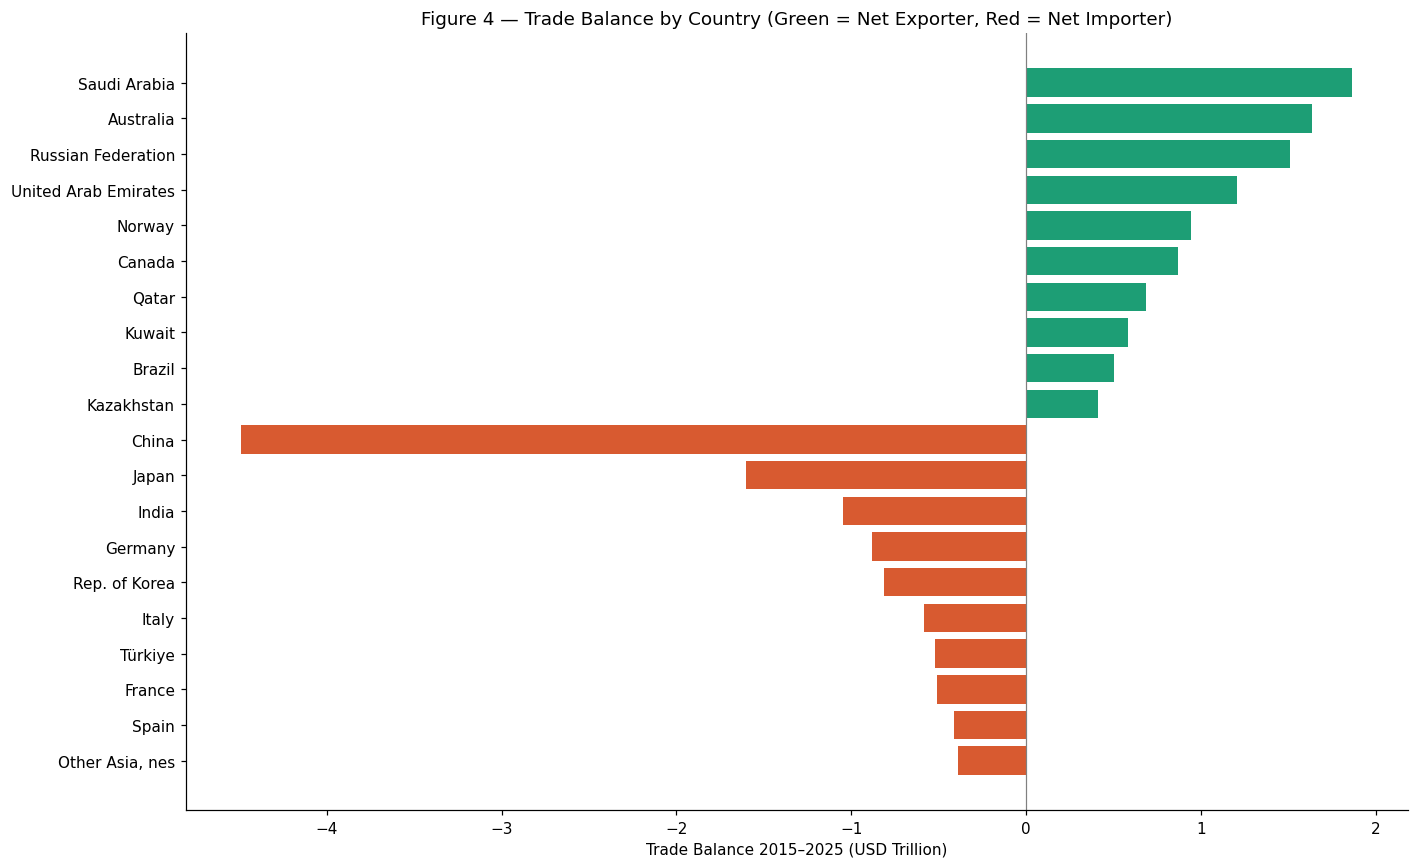

Insight: China and Germany are the largest net exporters.
The USA is the largest net importer — a major driver of container shipping demand on trans-Pacific routes.


In [8]:
# ── FIGURE 4 — Trade Balance: Top Net Exporters vs Net Importers ──────────

pivot = comtrade.pivot_table(
    index='reporter_country',
    columns='flow_direction',
    values='trade_value_usd',
    aggfunc='sum'
).reset_index()
pivot.columns.name = None

if 'Export' in pivot.columns and 'Import' in pivot.columns:
    pivot['balance_T'] = (pivot['Export'].fillna(0) - pivot['Import'].fillna(0)) / 1e12

    top_exporters = pivot.nlargest(10, 'balance_T')[['reporter_country','balance_T']]
    top_importers = pivot.nsmallest(10, 'balance_T')[['reporter_country','balance_T']]
    combined_bal  = pd.concat([top_exporters, top_importers])

    colors_bal = ['#1D9E75' if v > 0 else '#D85A30' for v in combined_bal['balance_T']]

    plt.figure(figsize=(13, 8))
    plt.barh(combined_bal['reporter_country'], combined_bal['balance_T'], color=colors_bal)
    plt.axvline(0, color='gray', lw=0.8)
    plt.xlabel('Trade Balance 2015–2025 (USD Trillion)')
    plt.title('Figure 4 — Trade Balance by Country (Green = Net Exporter, Red = Net Importer)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{CLEAN_DIR}/fig4_trade_balance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Insight: China and Germany are the largest net exporters.')
    print('The USA is the largest net importer — a major driver of container shipping demand on trans-Pacific routes.')

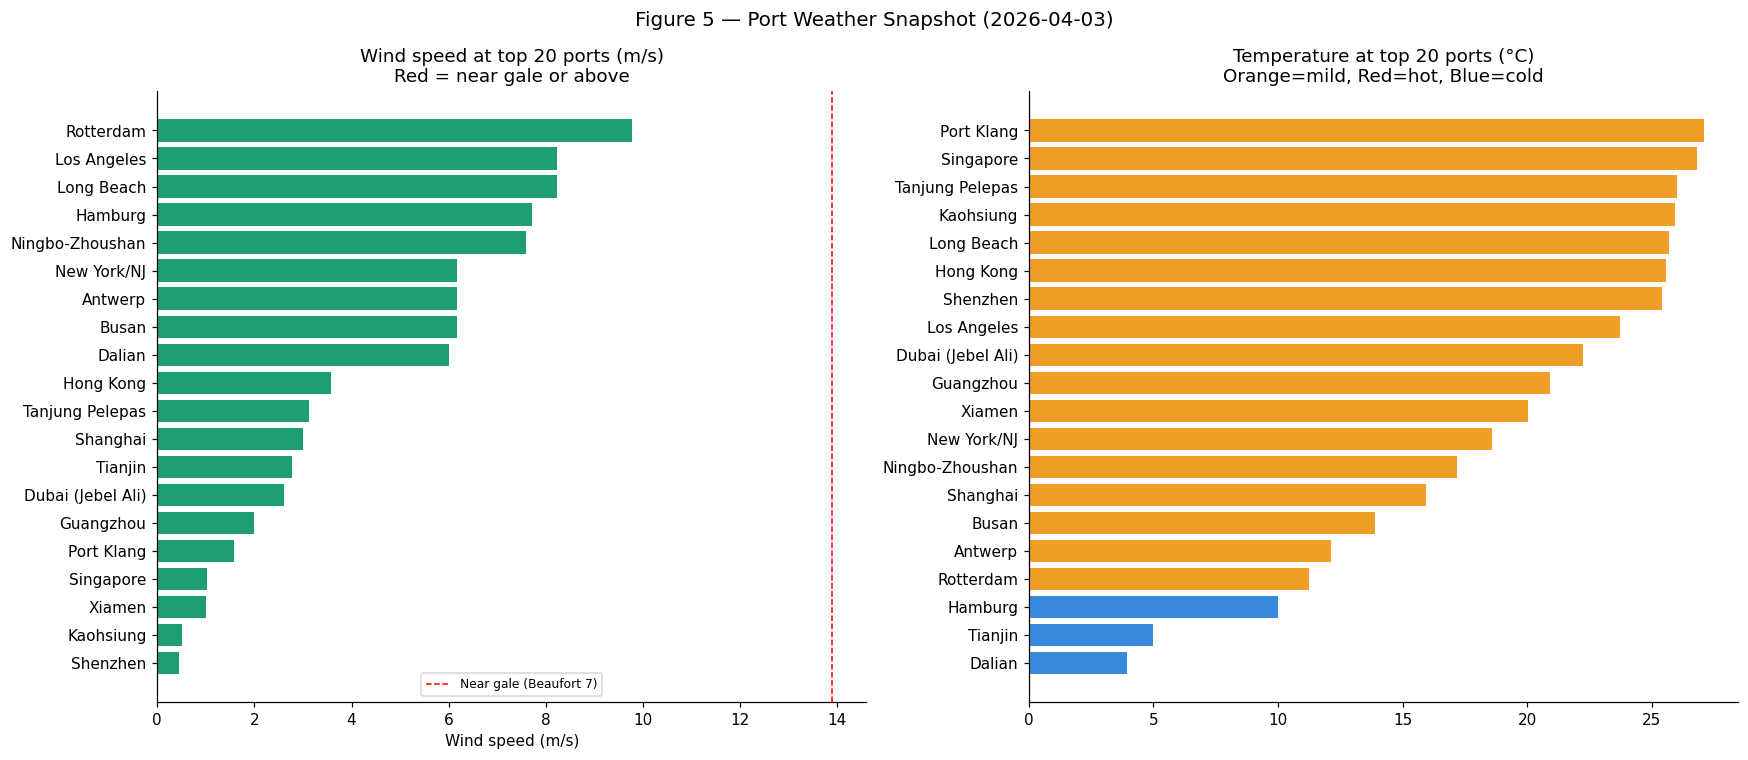

Insight: 0 of 20 ports at near-gale or above wind conditions.
Ports with high Beaufort numbers face operational delays — vessel departures may be deferred.


In [9]:
# ── FIGURE 5 — Port Weather: Wind Risk at Top 20 Ports ───────────────────

w = weather.sort_values('wind_speed_ms', ascending=False)
risk_colors = ['#D85A30' if v else '#1D9E75' for v in w['port_risk_flag']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# wind speed
axes[0].barh(w['port_name'], w['wind_speed_ms'], color=risk_colors)
axes[0].axvline(13.9, color='red', ls='--', lw=1, label='Near gale (Beaufort 7)')
axes[0].set_title('Wind speed at top 20 ports (m/s)\nRed = near gale or above')
axes[0].set_xlabel('Wind speed (m/s)')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# temperature
t = weather.sort_values('temp_c', ascending=False)
temp_c = ['#D85A30' if v > 28 else '#378ADD' if v < 10 else '#EF9F27' for v in t['temp_c']]
axes[1].barh(t['port_name'], t['temp_c'], color=temp_c)
axes[1].set_title('Temperature at top 20 ports (°C)\nOrange=mild, Red=hot, Blue=cold')
axes[1].axvline(0, color='gray', ls='--', lw=0.8)
axes[1].invert_yaxis()

n_risk = weather['port_risk_flag'].sum()
fetch_date = weather['fetch_date'].iloc[0] if 'fetch_date' in weather.columns else 'today'
plt.suptitle(f'Figure 5 — Port Weather Snapshot ({fetch_date})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/fig5_port_weather.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: {n_risk} of 20 ports at near-gale or above wind conditions.')
print('Ports with high Beaufort numbers face operational delays — vessel departures may be deferred.')

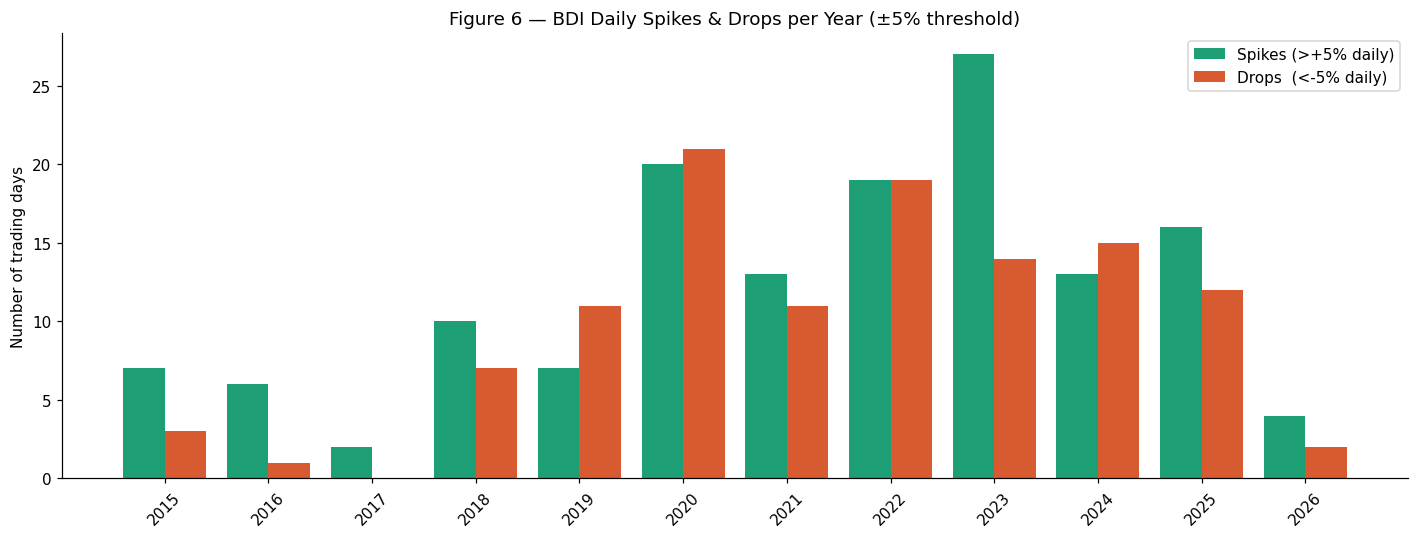

Insight: 2020 and 2021 have the highest combined volatility.
2021 shows more spikes than drops — consistent with the post-COVID demand surge.
2016 shows more drops — consistent with the historic BDI low driven by oversupply.


In [10]:
# ── FIGURE 6 — BDI Spikes & Drops Per Year ───────────────────────────────

bdi_y = bdi.copy()
bdi_y['year_int'] = bdi_y['date'].dt.year
spikes = bdi_y.groupby('year_int')['is_spike'].sum()
drops  = bdi_y.groupby('year_int')['is_drop'].sum()

x = np.arange(len(spikes))
plt.figure(figsize=(13, 5))
plt.bar(x - 0.2, spikes.values, 0.4, label='Spikes (>+5% daily)', color='#1D9E75')
plt.bar(x + 0.2, drops.values,  0.4, label='Drops  (<-5% daily)', color='#D85A30')
plt.xticks(x, spikes.index.astype(str), rotation=45)
plt.title('Figure 6 — BDI Daily Spikes & Drops per Year (±5% threshold)')
plt.ylabel('Number of trading days')
plt.legend()
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/fig6_bdi_spikes_drops.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: 2020 and 2021 have the highest combined volatility.')
print('2021 shows more spikes than drops — consistent with the post-COVID demand surge.')
print('2016 shows more drops — consistent with the historic BDI low driven by oversupply.')

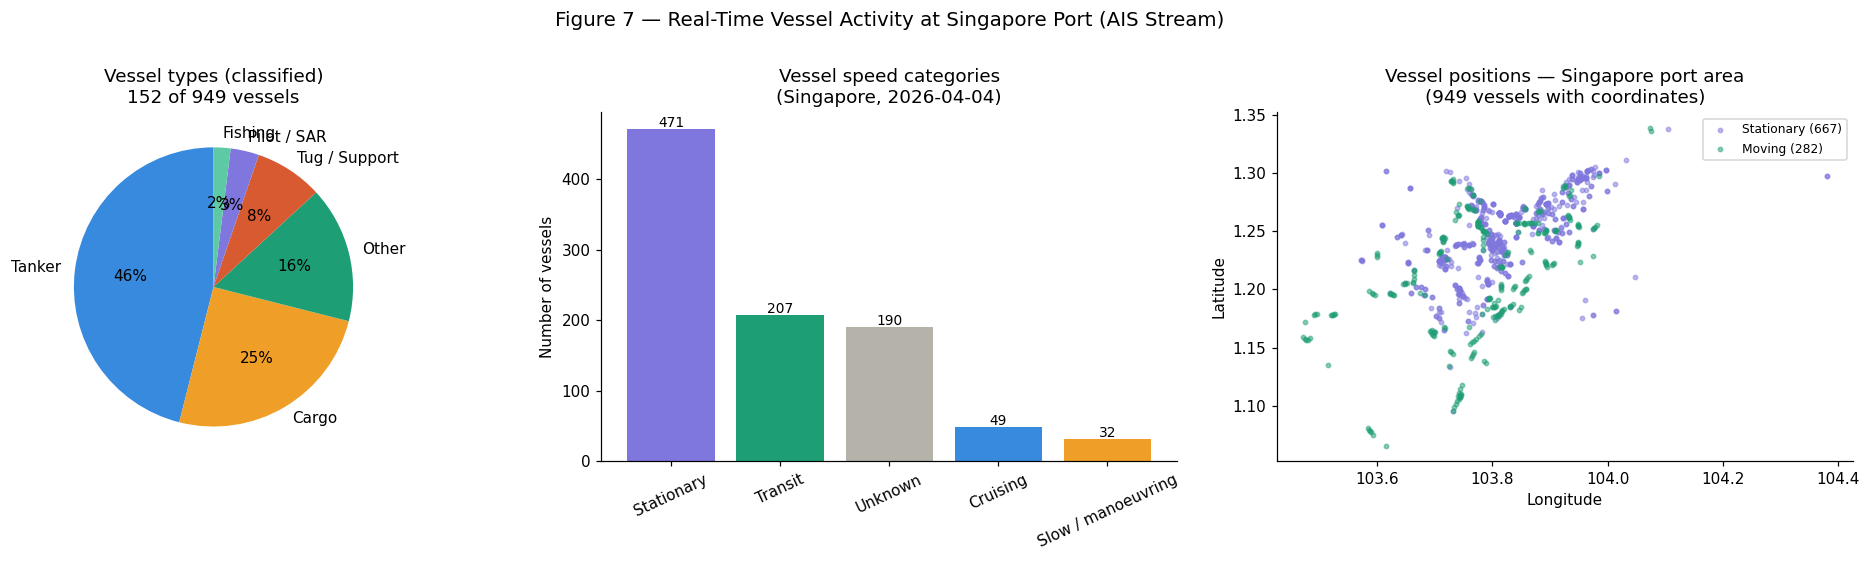

Insight: 29% of vessels in Singapore port area are actively moving.
High proportion of stationary vessels is consistent with Singapore port operations — vessels anchor to await berth allocation.


In [11]:
# ── FIGURE 7 — AIS: Vessel Activity at Singapore Port ────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart A: vessel category pie (known types only)
if 'vessel_category' in ais.columns:
    known_ais = ais[ais['vessel_category'] != 'Unknown']
    cat_counts = known_ais['vessel_category'].value_counts()
    pie_colors = ['#378ADD','#EF9F27','#1D9E75','#D85A30','#7F77DD','#5DCAA5']
    if len(cat_counts) > 0:
        axes[0].pie(
            cat_counts.values,
            labels=cat_counts.index,
            autopct='%1.0f%%',
            colors=pie_colors[:len(cat_counts)],
            startangle=90
        )
        axes[0].set_title(f'Vessel types (classified)\n{len(known_ais)} of {len(ais)} vessels')
    else:
        axes[0].text(0.5, 0.5, 'Run fix notebook first', ha='center', transform=axes[0].transAxes)

# Chart B: speed category bar
if 'speed_category' in ais.columns:
    spd = ais['speed_category'].value_counts()
    spd_colors = {'Stationary':'#7F77DD','Slow / manoeuvring':'#EF9F27',
                  'Transit':'#1D9E75','Cruising':'#378ADD','Unknown':'#B4B2A9'}
    axes[1].bar(spd.index, spd.values,
                color=[spd_colors.get(s,'#888') for s in spd.index])
    axes[1].set_title(f'Vessel speed categories\n(Singapore, {ais["date"].iloc[0] if "date" in ais.columns else "today"})')
    axes[1].set_ylabel('Number of vessels')
    axes[1].tick_params(axis='x', rotation=25)
    for i, (idx, val) in enumerate(spd.items()):
        axes[1].text(i, val + 3, str(val), ha='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Run fix notebook first', ha='center', transform=axes[1].transAxes)

# Chart C: vessel positions scatter
pos = ais.dropna(subset=['latitude','longitude'])
if len(pos) > 0 and 'is_moving' in pos.columns:
    mv  = pos[pos['is_moving'] == True]
    st  = pos[pos['is_moving'] == False]
    axes[2].scatter(st['longitude'], st['latitude'], c='#7F77DD', s=8, alpha=0.5, label=f'Stationary ({len(st)})')
    axes[2].scatter(mv['longitude'], mv['latitude'], c='#1D9E75', s=8, alpha=0.5, label=f'Moving ({len(mv)})')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    axes[2].set_title(f'Vessel positions — Singapore port area\n({len(pos)} vessels with coordinates)')
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'No coordinate data', ha='center', transform=axes[2].transAxes)

plt.suptitle('Figure 7 — Real-Time Vessel Activity at Singapore Port (AIS Stream)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/fig7_ais_activity.png', dpi=150, bbox_inches='tight')
plt.show()

moving_pct = int(ais['is_moving'].mean()*100) if 'is_moving' in ais.columns else 'N/A'
print(f'Insight: {moving_pct}% of vessels in Singapore port area are actively moving.')
print('High proportion of stationary vessels is consistent with Singapore port operations — vessels anchor to await berth allocation.')

In [12]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────

charts = sorted(glob.glob(f'{CLEAN_DIR}/fig*.png'))
print('='*55)
print('EDA COMPLETE')
print('='*55)
print(f'Combined dataset: {combined.shape[0]:,} rows x {combined.shape[1]} columns')
print(f'Sources merged:   {combined["source"].nunique()}')
print()
print('Charts generated:')
for c in charts:
    kb = os.path.getsize(c)//1024
    print(f'  {os.path.basename(c)} ({kb} KB)')
print()
print('Files saved to data/clean/:')
for f in ['shipping_combined.csv','comtrade_limitation_note.txt','aisstream_appraisal_note.txt']:
    path = f'{CLEAN_DIR}/{f}'
    if os.path.exists(path):
        kb = os.path.getsize(path)//1024
        print(f'  {f} ({kb} KB)')
print()
print('Next step: run 05_bigquery_upload.ipynb')

EDA COMPLETE
Combined dataset: 20,216 rows x 102 columns
Sources merged:   4

Charts generated:
  fig1_top_exporters.png (67 KB)
  fig2_bdi_trend.png (191 KB)
  fig3_bdi_vs_trade.png (83 KB)
  fig4_trade_balance.png (77 KB)
  fig5_port_weather.png (151 KB)
  fig6_bdi_spikes_drops.png (50 KB)
  fig7_ais_activity.png (200 KB)

Files saved to data/clean/:
  shipping_combined.csv (6300 KB)

Next step: run 05_bigquery_upload.ipynb
